# Feature Selection 

After identifying the Biopsy target, two datasets were created with and without the three other diagnostic tests ("Hinselmann", "Schiller", and "Citology") to show their predictive power in addition to identifying which risk factors are associated with a positive Biopsy. The class imbalance was accounted for using class weighting versus SMOTE, with a higher PR-AUC. The dataset with diagnostic variables also had a higher PR-AUC, expectedly, but feature selection is still necessary to determine which variables contribute most to model preditions. 

## Setup + Import Data

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns


figures = Path("../04_FIGURES")
results = Path("../05_RESULTS")
figures.mkdir(parents=True, exist_ok=True)
results.mkdir(parents=True, exist_ok=True)
data = Path("../01_DATA/test_train_split")
data.mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(data / "X_train.csv")
y_train = train_df["Biopsy"]
x_train = train_df.drop(columns=["Biopsy"])
print(x_train.shape)
x_train.head()

(584, 35)


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,Dx:CIN,Dx:HPV,Dx,smokes_missing,hormonal_contraceptives_missing,iud_missing,stds_missing,number_of_sexual_partners_missing,first_sexual_intercourse_missing,num_of_pregnancies_missing
0,24,3.0,17.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,1,1,1,0,0,0
1,17,2.0,12.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,1,1,1,0,0,1
2,24,1.0,16.0,3.0,0.0,0.0,0.0,1.0,3.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,28,3.0,15.0,5.0,1.0,12.0,12.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,21,1.0,17.0,2.0,0.0,0.0,0.0,1.0,3.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [50]:
diag_train_df = pd.read_csv(data / "Diag_X_train.csv")
diag_y_train = diag_train_df["Biopsy"]
diag_x_train = diag_train_df.drop(columns=["Biopsy"])
print(diag_x_train.shape)
diag_x_train.head()

(584, 38)


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,Hinselmann,Schiller,Citology,smokes_missing,hormonal_contraceptives_missing,iud_missing,stds_missing,number_of_sexual_partners_missing,first_sexual_intercourse_missing,num_of_pregnancies_missing
0,24,3.0,17.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,1,1,1,0,0,0
1,17,2.0,12.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,1,1,1,0,0,1
2,24,1.0,16.0,3.0,0.0,0.0,0.0,1.0,3.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,28,3.0,15.0,5.0,1.0,12.0,12.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,21,1.0,17.0,2.0,0.0,0.0,0.0,1.0,3.0,0.0,...,1,1,0,0,0,0,0,0,0,0


Now to create a variable to account for the feature_missing columns that were grouped into 7 columns across the 19 raw data columns. 

In [51]:
missing_cols = [c for c in x_train.columns if c.endswith("_missing")]
print(f"{len(missing_cols)} feature missingness columns")

7 feature missingness columns


## Variance Test 
Looking at which variables have the least amount of variance between rows to potentially drop. The first feature set without the diagnostic tests will be tested first, followed by the second feature set including the diagnostic tests. 

In [52]:
from sklearn.feature_selection import VarianceThreshold 

vt = VarianceThreshold(threshold=0.01)
vt.fit(x_train)

cols_low_var = x_train.columns[~vt.get_support()]
print("Columns with 0.01 variance:", list(cols_low_var))

x_train_new = x_train.drop(columns=cols_low_var)
print(x_train_new.shape)

Columns with 0.01 variance: ['STDs:vaginal condylomatosis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:Hepatitis B', 'STDs:HPV', 'first_sexual_intercourse_missing']
(584, 28)


In [53]:
vt.fit(diag_x_train)

diag_cols_low_var = diag_x_train.columns[~vt.get_support()]
print("Columns with 0.01 variance:", list(diag_cols_low_var))

diag_x_train_new = diag_x_train.drop(columns=diag_cols_low_var)
print(diag_x_train_new.shape)

Columns with 0.01 variance: ['STDs:vaginal condylomatosis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:Hepatitis B', 'STDs:HPV', 'first_sexual_intercourse_missing']
(584, 31)


Since columns with 0 variance for STDs were already dropped, this variance tests indentifies columns with very little variance (0.01%) to drop, including the first_sexual_intercouse_missing column as very few patients had this missing data. 

## Correlation
Since our target, Biopsy, is binary, a point-biserial correlation must be used. 

In [54]:
from scipy.stats import pointbiserialr

cor_rows = []
for col in x_train_new:
    r, p = pointbiserialr(y_train, x_train_new[col])
    cor_rows.append({"Feature": col, "Cor": r, "P-value": p})

cor_df = pd.DataFrame(cor_rows).sort_values("Cor", key=abs, ascending=False)
cor_df.head(20)

,Feature,Cor,P-value
11,STDs,0.139714,0.000710
21,Dx,0.113626,0.005979
12,STDs (number),0.112408,0.006543
16,STDs:HIV,0.108600,0.008625
20,Dx:HPV,0.108600,0.008625
14,STDs:vulvo-perineal condylomatosis,0.107222,0.009513
17,STDs: Number of diagnosis,0.106683,0.009881
13,STDs:condylomatosis,0.103270,0.012526
18,Dx:Cancer,0.101368,0.014256
23,hormonal_contraceptives_missing,-0.094970,0.021714


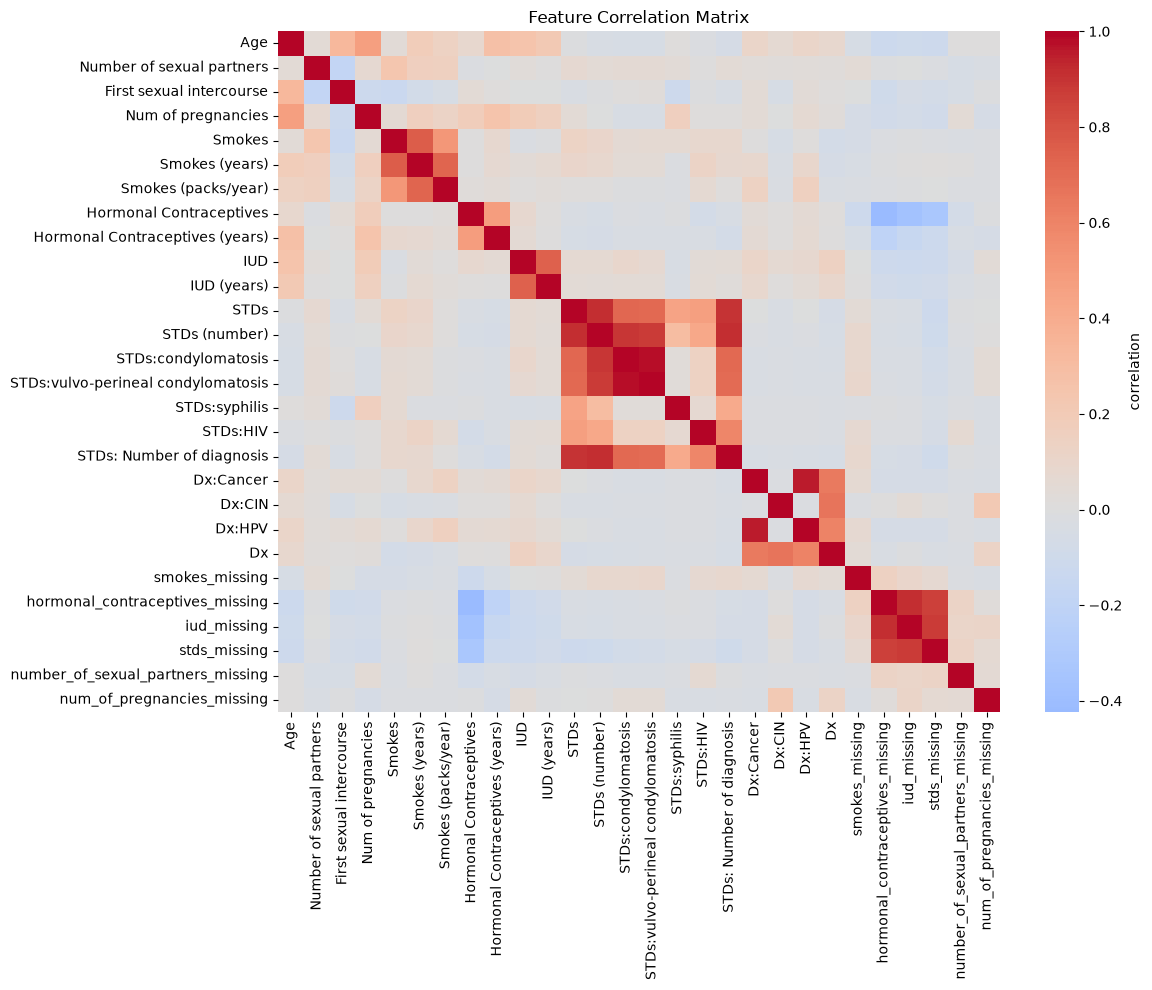

In [55]:
cor_matrix = x_train_new.corr()

plt.figure(figsize=(12,10))
sns.heatmap(cor_matrix, cmap="coolwarm", center=0, cbar_kws={"label": "correlation"})
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(figures / "feature_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

Based on the correlation table and matrix heatmap for the risk factor-only feature dataset, it appears that the STDs, Dx, STDs(number), STDs:HIV, and Dx:HPV have the highest correlation with p-values under 0.05 to a positive Biopsy; however, they are low correlations of only ~0.1, meaning they do not show obvious influence on the result. 

In [67]:
diag_cor_rows = []
for col in diag_x_train_new:
    r, p = pointbiserialr(y_train, diag_x_train_new[col])
    diag_cor_rows.append({"Feature": col, "Cor": r, "P-value": p})

diag_cor_df = pd.DataFrame(diag_cor_rows).sort_values("Cor", key=abs, ascending=False)
diag_cor_df.head(20)

,Feature,Cor,P-value
23,Schiller,0.738084,1.570776e-101
22,Hinselmann,0.574888,1.127928e-52
24,Citology,0.313320,9.080711e-15
11,STDs,0.139714,7.099062e-04
21,Dx,0.113626,5.979212e-03
12,STDs (number),0.112408,6.542809e-03
16,STDs:HIV,0.108600,8.624836e-03
20,Dx:HPV,0.108600,8.624836e-03
14,STDs:vulvo-perineal condylomatosis,0.107222,9.512755e-03
17,STDs: Number of diagnosis,0.106683,9.881161e-03


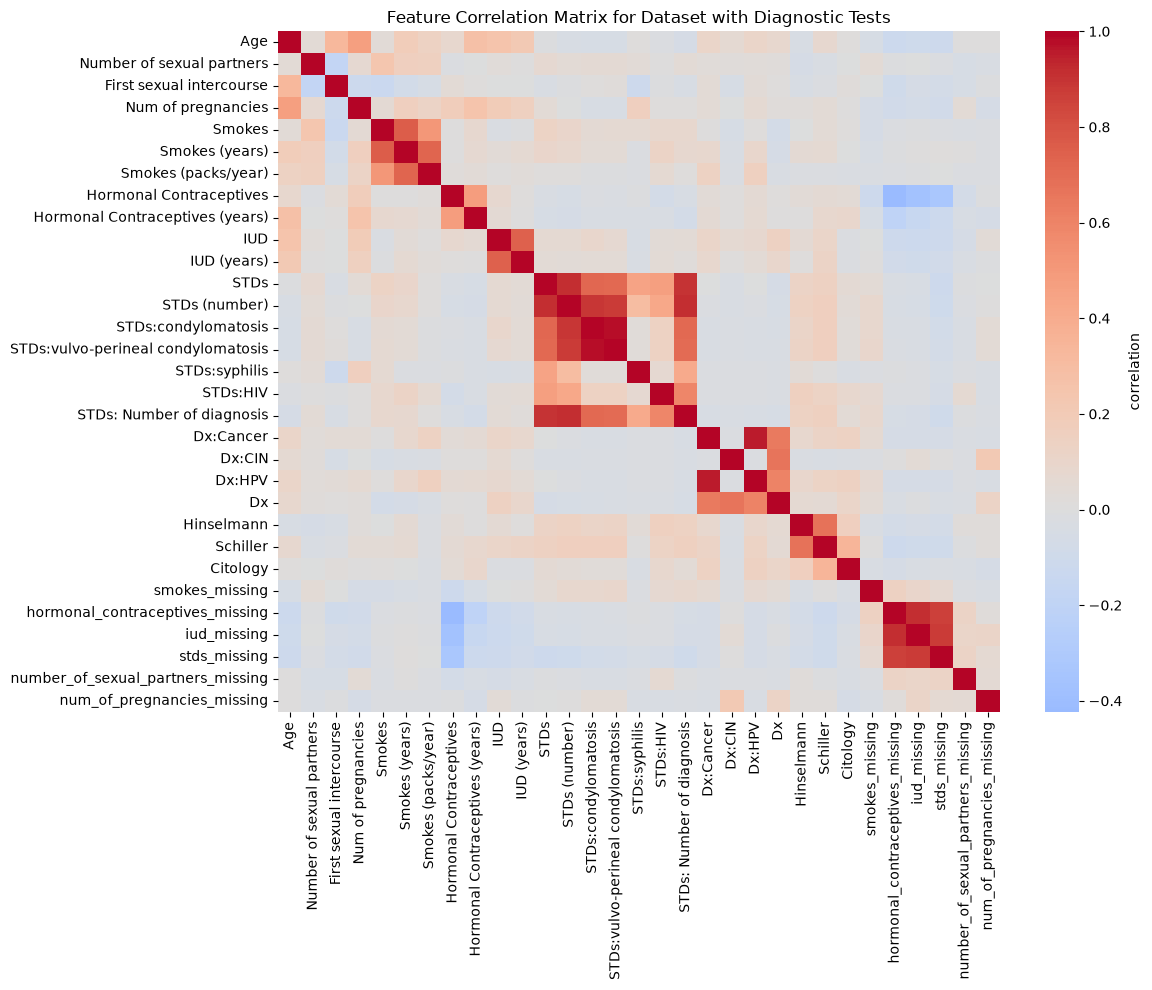

In [68]:
diag_cor_matrix = diag_x_train_new.corr()

plt.figure(figsize=(12,10))
sns.heatmap(diag_cor_matrix, cmap="coolwarm", center=0, cbar_kws={"label": "correlation"})
plt.title("Feature Correlation Matrix for Dataset with Diagnostic Tests")
plt.tight_layout()
plt.savefig(figures / "diag_feature_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

For the correlation table and matrix heatmap for the dataset including the diagnostic tests, it was expected and shown that the three tests had the highest and significant correlations, followed by STDs and Dx. 

## Mutual Information 

Now to investigate any non-linear correlations between features and results that may have been missed in the previous section by flagging binary and categorical columns for appropriate mutual information analysis. 

In [56]:
from sklearn.feature_selection import mutual_info_classif 

bi_cat_col = [x_train_new[c].nunique() <= 10 for c in x_train_new.columns]

mi = mutual_info_classif(x_train_new, y_train, discrete_features=bi_cat_col, random_state=42)
mi_series = pd.Series(mi, index=x_train_new.columns).sort_values(ascending=False)
mi_series.head(20)

STDs (number)                         0.008954
Hormonal Contraceptives (years)       0.008907
hormonal_contraceptives_missing       0.008217
STDs                                  0.007151
STDs: Number of diagnosis             0.007119
Age                                   0.006027
First sexual intercourse              0.005594
Num of pregnancies                    0.004920
iud_missing                           0.004301
Dx                                    0.004205
STDs:vulvo-perineal condylomatosis    0.004048
STDs:condylomatosis                   0.003809
STDs:HIV                              0.003641
Dx:HPV                                0.003641
stds_missing                          0.003580
Dx:Cancer                             0.003279
Dx:CIN                                0.002399
Hormonal Contraceptives               0.001583
IUD                                   0.001333
smokes_missing                        0.001280
dtype: float64

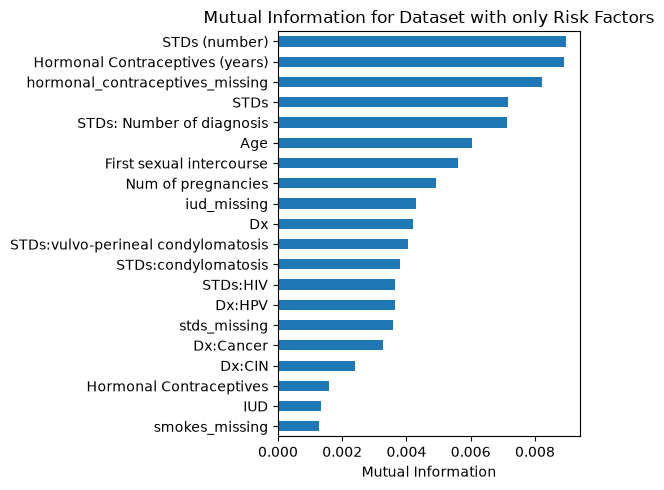

In [71]:
mi_series.head(20).plot(kind="barh", figsize=(6,5))
plt.gca().invert_yaxis()
plt.title("Mutual Information for Dataset with only Risk Factors")
plt.xlabel("Mutual Information")
plt.tight_layout()
plt.savefig(figures / "mutual_information_top20.png", dpi=150, bbox_inches="tight")
plt.show()

For the first feature set, all values are small, meaning that the variables do not have much impact on reducing uncertainty about Biopsy results. However, the top variables stand out as STDs and STDs(number) like from the previous correlation analysis, as well as hormonal contraceptive years and reported/missing data.

In [69]:
diag_bi_cat_col = [diag_x_train_new[c].nunique() <= 10 for c in diag_x_train_new.columns]

diag_mi = mutual_info_classif(diag_x_train_new, y_train, discrete_features=diag_bi_cat_col, random_state=42)
diag_mi_series = pd.Series(diag_mi, index=diag_x_train_new.columns).sort_values(ascending=False)
diag_mi_series.head(20)

Schiller                              0.137296
Hinselmann                            0.069838
Citology                              0.025248
STDs (number)                         0.008954
Hormonal Contraceptives (years)       0.008907
hormonal_contraceptives_missing       0.008217
STDs                                  0.007151
STDs: Number of diagnosis             0.007119
Age                                   0.006027
First sexual intercourse              0.005594
Num of pregnancies                    0.004920
iud_missing                           0.004301
Dx                                    0.004205
STDs:vulvo-perineal condylomatosis    0.004048
STDs:condylomatosis                   0.003809
STDs:HIV                              0.003641
Dx:HPV                                0.003641
stds_missing                          0.003580
Dx:Cancer                             0.003279
Dx:CIN                                0.002399
dtype: float64

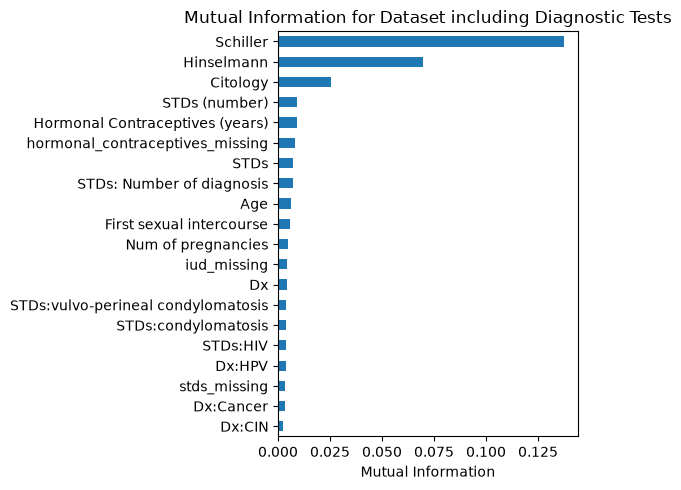

In [70]:
diag_mi_series.head(20).plot(kind="barh", figsize=(6,5))
plt.gca().invert_yaxis()
plt.title("Mutual Information for Dataset including Diagnostic Tests")
plt.xlabel("Mutual Information")
plt.tight_layout()
plt.savefig(figures / "diag_mutual_information_top20.png", dpi=150, bbox_inches="tight")
plt.show()

As expected, the diagnositc tests have significant, high correlations with the Biopsy results, followed by STDs (number) and other leading risk factors as seen previously. 

## Wrapper Methods
To train models on different feature subsets instead of each feature individually (like the tests above) to keep the best-scoring subset in cross-validation. Recursive Feature Elimination with Cross Validation (RFECV) will be used to drop the weakest feature and then check again with CV. 

In [76]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import StratifiedKFold

cv= StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

rfecv = RFECV(estimator=LogisticRegression(class_weight="balanced", max_iter=5000), step=1, cv=cv, scoring="average_precision", min_features_to_select=5)
rfecv.fit(x_train_new, y_train)

wrapper_feats = x_train_new.columns[rfecv.support_].tolist()
print(f"RFECV selected {len(wrapper_feats)} of {x_train_new.shape[1]} features")
print(wrapper_feats)

RFECV selected 18 of 28 features
['Smokes', 'Hormonal Contraceptives', 'IUD', 'STDs', 'STDs (number)', 'STDs:condylomatosis', 'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:HIV', 'STDs: Number of diagnosis', 'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'smokes_missing', 'hormonal_contraceptives_missing', 'number_of_sexual_partners_missing', 'num_of_pregnancies_missing']


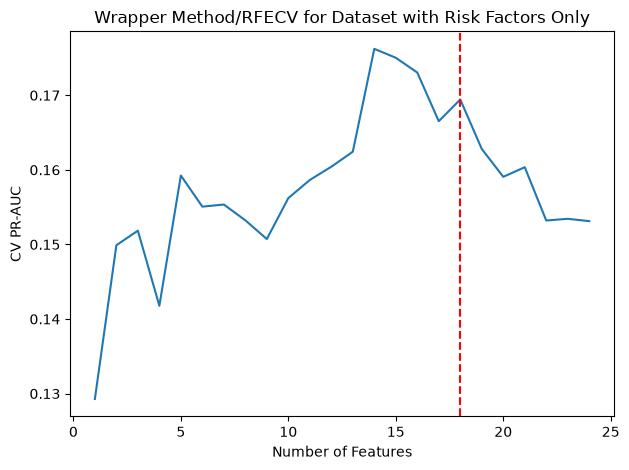

In [77]:
plt.plot(range(1, len(rfecv.cv_results_["mean_test_score"]) + 1), rfecv.cv_results_["mean_test_score"])
plt.title("Wrapper Method/RFECV for Dataset with Risk Factors Only")
plt.xlabel("Number of Features")
plt.ylabel("CV PR-AUC")
plt.axvline(len(wrapper_feats), color="red", linestyle="--")
plt.tight_layout()
plt.savefig(figures/ "rfecv_curve.png", dpi=150, bbox_inches="tight")
plt.show()

From this wrapper method, about 10 features were identifyed to be dropped in the first dataset in our selection as this subset of 18 variables scored best on cross validation. 

In [78]:
rfecv.fit(diag_x_train_new, y_train)

diag_wrapper_feats = diag_x_train_new.columns[rfecv.support_].tolist()
print(f"RFECV selected {len(wrapper_feats)} of {diag_x_train_new.shape[1]} features in dataset with diagnostic tests")
print(diag_wrapper_feats)

RFECV selected 18 of 31 features in dataset with diagnostic tests
['STDs', 'STDs:condylomatosis', 'STDs:syphilis', 'Dx:CIN', 'Hinselmann', 'Schiller', 'Citology', 'hormonal_contraceptives_missing']


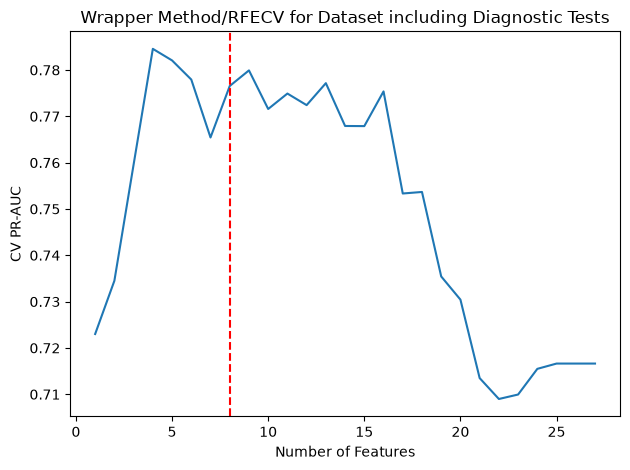

In [79]:
plt.plot(range(1, len(rfecv.cv_results_["mean_test_score"]) + 1), rfecv.cv_results_["mean_test_score"])
plt.title("Wrapper Method/RFECV for Dataset including Diagnostic Tests")
plt.xlabel("Number of Features")
plt.ylabel("CV PR-AUC")
plt.axvline(len(diag_wrapper_feats), color="red", linestyle="--")
plt.tight_layout()
plt.savefig(figures/ "diag_rfecv_curve.png", dpi=150, bbox_inches="tight")
plt.show()

The wrapper method similarly chose 18 features, but now including the diagnostic tests. 

## Colinearity Check
Need to check if two variables in the feature sets are highly correlated with each other as that can destabilize model coefficients. 

In [60]:
high_cor = (cor_matrix.where(np.triu(np.ones(cor_matrix.shape), k=1).astype(bool)).stack().reset_index())
high_cor.columns = ["feature_1", "feature_2", "correlation"]
high_cor = high_cor[high_cor["correlation"].abs() > 0.8].sort_values("correlation", key=abs, ascending=False)
high_cor

,feature_1,feature_2,correlation
378,STDs:condylomatosis,STDs:vulvo-perineal condylomatosis,0.981099
524,Dx:Cancer,Dx:HPV,0.959929
668,hormonal_contraceptives_missing,iud_missing,0.919955
320,STDs,STDs (number),0.917185
353,STDs (number),STDs: Number of diagnosis,0.914630
325,STDs,STDs: Number of diagnosis,0.896065
349,STDs (number),STDs:condylomatosis,0.893677
350,STDs (number),STDs:vulvo-perineal condylomatosis,0.880151
697,iud_missing,stds_missing,0.878987
669,hormonal_contraceptives_missing,stds_missing,0.855787


In [61]:
to_drop = set()
for _, row in high_cor.iterrows():
    f1, f2 = row["feature_1"], row["feature_2"]
    weaker = f1 if mi_series.get(f1, 0) < mi_series.get(f2,0) else f2
    to_drop.add(weaker) 

print("Dropping due to collinearity:", to_drop)

Dropping due to collinearity: {'STDs: Number of diagnosis', 'iud_missing', 'STDs', 'STDs:condylomatosis', 'Dx:Cancer', 'STDs:vulvo-perineal condylomatosis', 'stds_missing'}


In [62]:
from statsmodels.stats.outliers_influence import variance_inflation_factor 

x_vif_check = x_train_new.drop(columns=to_drop).assign(_const=1)
vif = pd.Series([variance_inflation_factor(x_vif_check.values, i) for i in range(x_vif_check.shape[1] -1)], index=x_train_new.drop(columns=to_drop).columns).sort_values(ascending=False)

vif.head(10)

Dx                         6.059918
Smokes (years)             4.294636
Dx:CIN                     3.796702
Dx:HPV                     3.458357
Smokes                     2.737416
IUD                        2.425863
IUD (years)                2.329330
Smokes (packs/year)        2.317900
Age                        1.918200
Hormonal Contraceptives    1.589692
dtype: float64

For the first dataset, many of the STD columns were expectedly dropped due to colinearity, as well as some of the missing columns, showing that patients were more likely to leave missing data in multiple columns. The VIF scores were under the threshold of 10, meaning that the correlation-based cleaning of the data was successful. 

In [80]:
diag_high_cor = (diag_cor_matrix.where(np.triu(np.ones(diag_cor_matrix.shape), k=1).astype(bool)).stack().reset_index())
diag_high_cor.columns = ["feature_1", "feature_2", "correlation"]
diag_high_cor = diag_high_cor[diag_high_cor["correlation"].abs() > 0.8].sort_values("correlation", key=abs, ascending=False)
diag_high_cor

,feature_1,feature_2,correlation
417,STDs:condylomatosis,STDs:vulvo-perineal condylomatosis,0.981099
578,Dx:Cancer,Dx:HPV,0.959929
833,hormonal_contraceptives_missing,iud_missing,0.919955
353,STDs,STDs (number),0.917185
389,STDs (number),STDs: Number of diagnosis,0.914630
358,STDs,STDs: Number of diagnosis,0.896065
385,STDs (number),STDs:condylomatosis,0.893677
386,STDs (number),STDs:vulvo-perineal condylomatosis,0.880151
865,iud_missing,stds_missing,0.878987
834,hormonal_contraceptives_missing,stds_missing,0.855787


In [81]:
diag_to_drop = set()
for _, row in diag_high_cor.iterrows():
    f1, f2 = row["feature_1"], row["feature_2"]
    weaker = f1 if diag_mi_series.get(f1, 0) < diag_mi_series.get(f2,0) else f2
    diag_to_drop.add(weaker) 

print("Dropping due to collinearity in dataset with diagnostic tests:", diag_to_drop)

Dropping due to collinearity in dataset with diagnostic tests: {'STDs: Number of diagnosis', 'iud_missing', 'STDs', 'STDs:condylomatosis', 'Dx:Cancer', 'STDs:vulvo-perineal condylomatosis', 'stds_missing'}


In [82]:
diag_x_vif_check = diag_x_train_new.drop(columns=to_drop).assign(_const=1)
diag_vif = pd.Series([variance_inflation_factor(diag_x_vif_check.values, i) for i in range(diag_x_vif_check.shape[1] -1)], index=diag_x_train_new.drop(columns=diag_to_drop).columns).sort_values(ascending=False)

diag_vif.head(10)

Dx                     6.176482
Smokes (years)         4.366978
Dx:CIN                 3.846109
Dx:HPV                 3.497355
Smokes                 2.774587
IUD                    2.438361
IUD (years)            2.375424
Smokes (packs/year)    2.337400
Schiller               2.247359
Hinselmann             2.011005
dtype: float64

The second dataset had identical results, meaning the diagnostic tests are no collinearly associated and impactful towards the Biopsy result. 

## FDR Correction 
This will control the false discovery rate across each test. 

In [63]:
from statsmodels.stats.multitest import multipletests

reject, qvals, _, _ = multipletests(cor_df["P-value"], alpha=0.05, method="fdr_bh")
cor_df["qvalue"] = qvals 
cor_df["fdr_significant"] = reject 

fdr_feats = cor_df.loc[cor_df["fdr_significant"], "Feature"].tolist() 
print(f"{len(fdr_feats)} of {len(cor_df)} features survive FDR correction at 5%")
cor_df.sort_values("qvalue").head(20)

9 of 28 features survive FDR correction at 5%


,Feature,Cor,P-value,qvalue,fdr_significant
11,STDs,0.139714,0.000710,0.019877,True
21,Dx,0.113626,0.005979,0.039525,True
12,STDs (number),0.112408,0.006543,0.039525,True
16,STDs:HIV,0.108600,0.008625,0.039525,True
20,Dx:HPV,0.108600,0.008625,0.039525,True
14,STDs:vulvo-perineal condylomatosis,0.107222,0.009513,0.039525,True
17,STDs: Number of diagnosis,0.106683,0.009881,0.039525,True
13,STDs:condylomatosis,0.103270,0.012526,0.043842,True
18,Dx:Cancer,0.101368,0.014256,0.044352,True
23,hormonal_contraceptives_missing,-0.094970,0.021714,0.060799,False


The FDR Correction identification of 9 variables passing at 5% from the 28 individual correlation p-values gives good evidence to consider, as many of the variables highly ranked, like STDs (number) and Dx have been consistent throughout the analysis. 

In [83]:
reject, qvals, _, _ = multipletests(diag_cor_df["P-value"], alpha=0.05, method="fdr_bh")
diag_cor_df["qvalue"] = qvals 
diag_cor_df["fdr_significant"] = reject 

diag_fdr_feats = diag_cor_df.loc[diag_cor_df["fdr_significant"], "Feature"].tolist() 
print(f"{len(diag_fdr_feats)} of {len(diag_cor_df)} features survive FDR correction at 5% for dataset with diagnostic tests")
diag_cor_df.sort_values("qvalue").head(20)

12 of 31 features survive FDR correction at 5% for dataset with diagnostic tests


,Feature,Cor,P-value,qvalue,fdr_significant
23,Schiller,0.738084,1.570776e-101,4.869406e-100,True
22,Hinselmann,0.574888,1.127928e-52,1.748288e-51,True
24,Citology,0.313320,9.080711e-15,9.383401e-14,True
11,STDs,0.139714,7.099062e-04,5.501773e-03,True
21,Dx,0.113626,5.979212e-03,3.063160e-02,True
12,STDs (number),0.112408,6.542809e-03,3.063160e-02,True
16,STDs:HIV,0.108600,8.624836e-03,3.063160e-02,True
20,Dx:HPV,0.108600,8.624836e-03,3.063160e-02,True
14,STDs:vulvo-perineal condylomatosis,0.107222,9.512755e-03,3.063160e-02,True
17,STDs: Number of diagnosis,0.106683,9.881161e-03,3.063160e-02,True


As expected, the three diagnostic tests also passed FDR correction. 

## Final Feature Set 

In [64]:
final_features = [f for f in wrapper_feats if f not in to_drop]

print(f"Final feature set: {len(final_features)} features")
print(final_features)

print("Feautres also FDR-significant:", [f for f in final_features if f in fdr_feats])
print("MI rank of each:", mi_series[final_features].sort_values(ascending=False))

Final feature set: 13 features
['Smokes', 'Hormonal Contraceptives', 'IUD', 'STDs (number)', 'STDs:syphilis', 'STDs:HIV', 'Dx:CIN', 'Dx:HPV', 'Dx', 'smokes_missing', 'hormonal_contraceptives_missing', 'number_of_sexual_partners_missing', 'num_of_pregnancies_missing']
Feautres also FDR-significant: ['STDs (number)', 'STDs:HIV', 'Dx:HPV', 'Dx']
MI rank of each: STDs (number)                        0.008954
hormonal_contraceptives_missing      0.008217
Dx                                   0.004205
STDs:HIV                             0.003641
Dx:HPV                               0.003641
Dx:CIN                               0.002399
Hormonal Contraceptives              0.001583
IUD                                  0.001333
STDs:syphilis                        0.001280
smokes_missing                       0.001280
Smokes                               0.000707
num_of_pregnancies_missing           0.000134
number_of_sexual_partners_missing    0.000008
dtype: float64


For the first feature set with only risk factors, the final feature selection from the wrapper method was used to limit the number to 13 as proven to be statistically significant in minorly influencing the Biopsy outcome. 

In [ ]:
train_selected = x_train[final_features].assign(Biopsy=y_train)
train_selected.to_csv(data / "../selected/x_train_selected.csv", index=False)

test_df = pd.read_csv(data / "../test_train_split/X_test.csv")
test_selected = test_df[final_features + ["Biopsy"]]
test_selected.to_csv(data / "../selected/x_test_selected.csv", index=False)

print(f"Saved: {data / "../selected/x_train_selected.csv"})
print(f"Saved: {data / "../selected/x_test_selected.csv"}")

Saved: ../01_DATA/test_train split/../selected/x_train_selected.csv
Saved: ../01_DATA/test_train split/../selected/x_test_selected.csv


To save the final selected variables in the training set for the first feature set. 

In [84]:
diag_final_features = [f for f in diag_wrapper_feats if f not in diag_to_drop]

print(f"Final feature set: {len(diag_final_features)} features in dataset with diagnostic tests")
print(diag_final_features)

print("Feautres also FDR-significant:", [f for f in diag_final_features if f in diag_fdr_feats])
print("MI rank of each:", diag_mi_series[diag_final_features].sort_values(ascending=False))

Final feature set: 6 features in dataset with diagnostic tests
['STDs:syphilis', 'Dx:CIN', 'Hinselmann', 'Schiller', 'Citology', 'hormonal_contraceptives_missing']
Feautres also FDR-significant: ['Hinselmann', 'Schiller', 'Citology']
MI rank of each: Schiller                           0.137296
Hinselmann                         0.069838
Citology                           0.025248
hormonal_contraceptives_missing    0.008217
Dx:CIN                             0.002399
STDs:syphilis                      0.001280
dtype: float64


With the diagnostic tests, the number of features selected drops dramatically as 6 as they have greater influence in the Biopsy outcomes. Finally, now to save the selected features in the second dataset. 

In [91]:
diag_train_selected = diag_x_train[diag_final_features].assign(Biopsy=y_train)
diag_train_selected.to_csv(data / "../selected/diag_x_train_selected.csv", index=False)

diag_test_df = pd.read_csv(data / "../test_train_split/Diag_X_test.csv")
diag_test_selected = diag_test_df[diag_final_features + ["Biopsy"]]
diag_test_selected.to_csv(data / "../selected/diag_x_test_selected.csv", index=False)

print(f"Saved: {data / "../selected/diag_x_train_selected.csv"}")
print(f"Saved: {data / "../selected/diag_x_test_selected.csv"}")

Saved: ../01_DATA/test_train_split/../selected/diag_x_train_selected.csv
Saved: ../01_DATA/test_train_split/../selected/diag_x_test_selected.csv


## Comparing CV PR-AUCs Before/After Feature Selection 

In [66]:
from sklearn.model_selection import cross_val_score 

full_score = cross_val_score(LogisticRegression(class_weight="balanced", max_iter=5000), x_train, y_train, cv=cv, scoring="average_precision")

selected_score = cross_val_score(LogisticRegression(class_weight="balanced", max_iter=5000), x_train[final_features], y_train,cv=cv, scoring="average_precision")

print(f"All Features PR_AUC = {full_score.mean():.2f} +/- {full_score.std():.2f}")
print(f"Selected Features PR_AUC = {selected_score.mean():.2f} +/- {selected_score.std():.2f}")

All Features PR_AUC = 0.15 +/- 0.09
Selected Features PR_AUC = 0.18 +/- 0.11


There is some improvement from our feature selection, but not a significant, meaning most of the risk factors do not hold significant influence on the Biopsy outcome. 

In [92]:
diag_full_score = cross_val_score(LogisticRegression(class_weight="balanced", max_iter=5000), diag_x_train, y_train, cv=cv, scoring="average_precision")

diag_selected_score = cross_val_score(LogisticRegression(class_weight="balanced", max_iter=5000), diag_x_train[diag_final_features], y_train,cv=cv, scoring="average_precision")

print(f"All Features PR_AUC in Dataset with Diagnostic Tests= {diag_full_score.mean():.2f} +/- {diag_full_score.std():.2f}")
print(f"Selected Features PR_AUC in Dataset with Diagnostic Tests= {diag_selected_score.mean():.2f} +/- {diag_selected_score.std():.2f}")

All Features PR_AUC in Dataset with Diagnostic Tests= 0.72 +/- 0.16
Selected Features PR_AUC in Dataset with Diagnostic Tests= 0.78 +/- 0.17


With feature selection, there was again some improvement in PR-AUC, but not much as the risk factors besides the diagnostic tests do not significantly affect Biopsy outcomes. 